# 03 - Mô hình OLS và diễn giải thống kê truyền thống

Yêu cầu: xây dựng 3 mô hình OLS đơn, mở rộng, đầy đủ; giải thích hệ số, p-value, R² và khoảng tin cậy.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for base in candidates:
        if (base / "data" / "wage_model.csv").exists():
            return base
        nested = base / "Machine Learning"
        if (nested / "data" / "wage_model.csv").exists():
            return nested
    raise FileNotFoundError("Không tìm thấy data/wage_model.csv. Hãy mở notebook trong folder Machine Learning.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "model_results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

eda_df = pd.read_csv(DATA_DIR / "wage_eda.csv")
model_df = pd.read_csv(DATA_DIR / "wage_model.csv")

print("Project root found.")
print("EDA data:", eda_df.shape)
print("Model data:", model_df.shape)


Project root found.
EDA data: (3010, 30)
Model data: (3010, 38)


In [2]:
target = "lwage"

simple_features = ["educ"]
extended_features = [
    "educ", "exper", "expersq", "IQ", "KWW",
    "black", "south", "smsa", "fatheduc", "motheduc",
    "married_2", "married_3", "married_4", "married_5", "married_6",
]
full_features = [col for col in model_df.columns if col != target]

feature_groups = {
    "M1_simple": simple_features,
    "M2_extended": extended_features,
    "M3_full": full_features,
}

X_full = model_df[full_features]
y = model_df[target]

print("Target:", target)
print("M1 features:", len(simple_features))
print("M2 features:", len(extended_features))
print("M3 features:", len(full_features))


Target: lwage
M1 features: 1
M2 features: 15
M3 features: 37


## 3.1 Fit 3 mô hình OLS


In [3]:
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col


def fit_ols(features):
    X = sm.add_constant(model_df[features], has_constant="add")
    return sm.OLS(model_df[target], X).fit()


ols_models = {
    name: fit_ols(features)
    for name, features in feature_groups.items()
}

summary = summary_col(
    list(ols_models.values()),
    model_names=list(ols_models.keys()),
    stars=True,
    float_format="%0.4f",
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.4f}",
        "Adj. R2": lambda x: f"{x.rsquared_adj:.4f}",
        "F-stat": lambda x: f"{x.fvalue:.2f}",
        "Prob(F)": lambda x: f"{x.f_pvalue:.4g}",
    },
)
print(summary)



                 M1_simple M2_extended  M3_full  
-------------------------------------------------
const            5.5709*** 4.8069***   4.6517*** 
                 (0.0388)  (0.0905)    (0.1022)  
educ             0.0521*** 0.0547***   0.0528*** 
                 (0.0029)  (0.0042)    (0.0044)  
exper                      0.0629***   0.0630*** 
                           (0.0069)    (0.0070)  
expersq                    -0.0018***  -0.0018***
                           (0.0003)    (0.0003)  
IQ                         0.0009      0.0010*   
                           (0.0006)    (0.0006)  
KWW                        0.0067***   0.0066*** 
                           (0.0011)    (0.0011)  
black                      -0.1199***  -0.1253***
                           (0.0189)    (0.0205)  
south                      -0.1227***  -0.1459***
                           (0.0148)    (0.0255)  
smsa                       0.1605***   0.1394*** 
                           (0.0154)    (0.0197)  

## 3.2 So sánh R², Adj. R², AIC, BIC


In [4]:
ols_compare = pd.DataFrame([
    {
        "model": name,
        "n_obs": int(model.nobs),
        "n_features": int(model.df_model),
        "r2": model.rsquared,
        "adj_r2": model.rsquared_adj,
        "aic": model.aic,
        "bic": model.bic,
        "f_stat": model.fvalue,
        "f_pvalue": model.f_pvalue,
    }
    for name, model in ols_models.items()
]).sort_values("adj_r2", ascending=False)

display(ols_compare.round(4))
ols_compare.to_csv(RESULT_DIR / "ols_model_comparison.csv", index=False)


,model,n_obs,n_features,r2,adj_r2,aic,bic,f_stat,f_pvalue
2,M3_full,3010,36,0.3382,0.3302,2481.8010,2704.1598,42.2083,0.0
1,M2_extended,3010,15,0.3256,0.3222,2496.9131,2593.0682,96.3466,0.0
0,M1_simple,3010,1,0.0987,0.0984,3341.5300,3353.5494,329.5367,0.0


## 3.3 Hệ số, p-value và khoảng tin cậy


In [5]:
def coefficient_table(model, model_name):
    conf = model.conf_int()
    out = pd.DataFrame({
        "model": model_name,
        "term": model.params.index,
        "coef": model.params.values,
        "std_err": model.bse.values,
        "t": model.tvalues.values,
        "p_value": model.pvalues.values,
        "ci_low": conf[0].values,
        "ci_high": conf[1].values,
    })
    out["pct_effect_exact"] = (np.exp(out["coef"]) - 1) * 100
    return out


coef_table = pd.concat(
    [coefficient_table(model, name) for name, model in ols_models.items()],
    ignore_index=True,
)

key_terms = [
    "educ", "exper", "expersq", "IQ", "KWW", "black", "south", "smsa",
    "fatheduc", "motheduc", "married_2", "married_3", "married_4",
    "married_5", "married_6",
]

full_key_coef = (
    coef_table
    .query("model == 'M3_full' and term in @key_terms")
    .sort_values("p_value")
)

display(full_key_coef.round(4))
coef_table.to_csv(RESULT_DIR / "ols_coefficients_all_models.csv", index=False)


,model,term,coef,std_err,t,p_value,ci_low,ci_high,pct_effect_exact
19,M3_full,educ,0.0528,0.0044,12.0697,0.0000,0.0442,0.0614,5.4226
49,M3_full,married_6,-0.1794,0.0179,-9.9994,0.0000,-0.2146,-0.1442,-16.4219
20,M3_full,exper,0.0630,0.0070,9.0250,0.0000,0.0493,0.0767,6.5027
28,M3_full,smsa,0.1394,0.0197,7.0699,0.0000,0.1008,0.1781,14.9626
26,M3_full,black,-0.1253,0.0205,-6.1080,0.0000,-0.1655,-0.0851,-11.7779
23,M3_full,KWW,0.0066,0.0011,5.9164,0.0000,0.0044,0.0088,0.6594
27,M3_full,south,-0.1459,0.0255,-5.7274,0.0000,-0.1959,-0.0960,-13.5791
21,M3_full,expersq,-0.0018,0.0003,-5.6433,0.0000,-0.0024,-0.0012,-0.1807
48,M3_full,married_5,-0.0889,0.0374,-2.3785,0.0174,-0.1622,-0.0156,-8.5081
47,M3_full,married_4,-0.0605,0.0305,-1.9871,0.0470,-0.1202,-0.0008,-5.8728


## 3.4 Biểu đồ hệ số mô hình đầy đủ


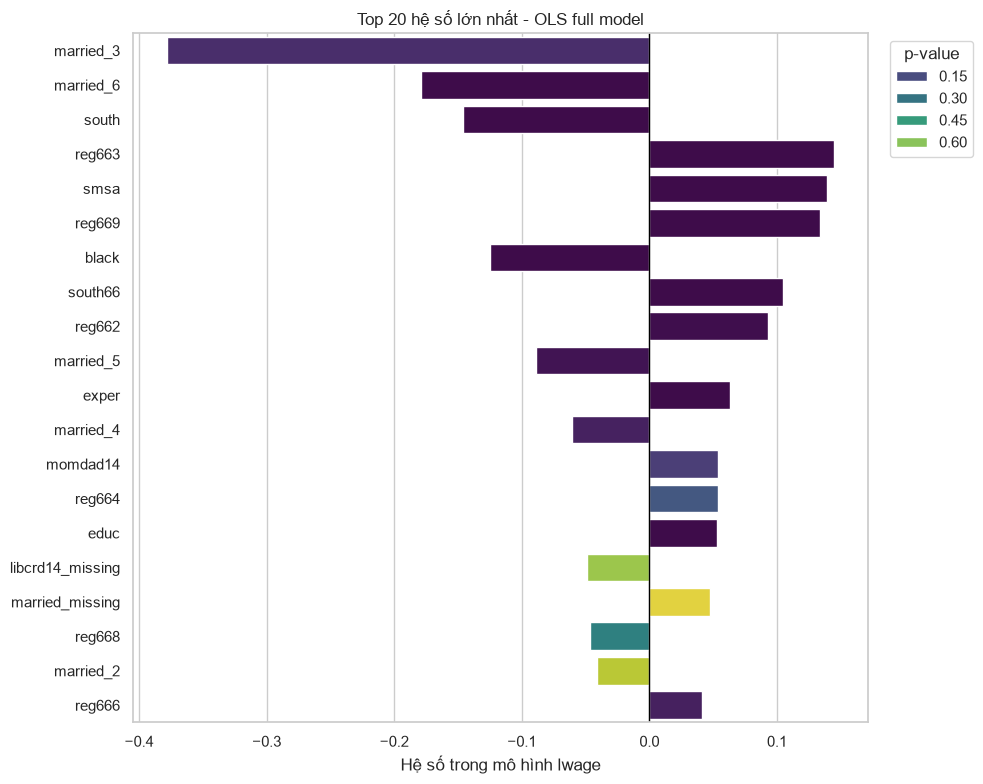

In [6]:
plot_df = (
    coef_table
    .query("model == 'M3_full' and term != 'const'")
    .assign(abs_coef=lambda x: x["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, y="term", x="coef", hue="p_value", dodge=False, palette="viridis")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top 20 hệ số lớn nhất - OLS full model")
plt.xlabel("Hệ số trong mô hình lwage")
plt.ylabel("")
plt.legend(title="p-value", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_ols_full_top_coefficients.png", dpi=200)
plt.show()


## Diễn giải ngắn

- Vì biến mục tiêu là `lwage`, hệ số có thể đọc gần đúng là phần trăm thay đổi của wage khi biến tăng 1 đơn vị, giữ các biến khác không đổi.
- `p_value < 0.05` thường được xem là có ý nghĩa thống kê ở mức 5%.
- R² cho biết mô hình giải thích được bao nhiêu phần biến động của `lwage`; với dữ liệu tiền lương, R² khoảng 0.3 là hợp lý vì còn nhiều yếu tố ngoài dữ liệu.
